# Battery Dataset Collection and Data Analysis

**Summer Internship 2026**

**Student:** Shrijan Samrat

**Guide:** Dr. Nimal Madhu M

## Objective

To study and analyze diffrent Battery Datasets and evaluate its suitability for State of Charge (SOC) and State of Health (SOH) estimation research. The analysis includes dataset structure, available parameters, data quality assessment, and machine learning suitability evaluation.


## Dataset Overview
### NASA Dataset

The NASA Battery Dataset is one of the most widely used public lithium-ion battery datasets for battery degradation analysis, SOC estimation, and SOH estimation research. The dataset contains charging, discharging, and impedance measurements collected from lithium-ion batteries under controlled laboratory conditions. Important parameters include voltage, current, temperature, capacity, and cycle information.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('metadata.csv')

df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [4]:
print(df.columns.tolist())

['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


In [5]:
print(df.shape)

(7565, 10)


In [6]:
df['type'].value_counts()

,count
type,
charge,2815
discharge,2794
impedance,1956


### Initial Observations
The NASA Battery Dataset metadata contains information about charging, discharging, and impedance measurement cycles. Each record is associated with a battery identifier, ambient temperature, test identifier, and experiment file reference. The dataset appears suitable for SOC and SOH estimation research because it includes operational and degradation-related battery information.

### Dataset Structure Analysis

The metadata file provides information about individual battery experiments and measurement cycles. Each record corresponds to a charge, discharge, or impedance operation performed on a lithium-ion battery. Important metadata fields include battery identifier, ambient temperature, experiment type, and file references that link to detailed measurement data.

The presence of charge, discharge, and impedance measurements makes the NASA Battery Dataset highly valuable for SOC estimation, SOH estimation, and battery degradation research.


The dataset contains three major operation categories:
1. Charge cycles
2. Discharge cycles
3. Impedance measurements

These measurements provide information regarding battery charging behavior, discharge characteristics, and internal electrochemical properties.

In [8]:
df['battery_id'].value_counts()

,count
battery_id,
B0006,616
B0007,616
B0005,616
B0034,486
B0036,486
B0033,486
B0018,319
B0042,275
B0044,275


In [9]:
df['ambient_temperature'].value_counts()

,count
ambient_temperature,
24,4658
4,2060
43,388
22,249
44,210


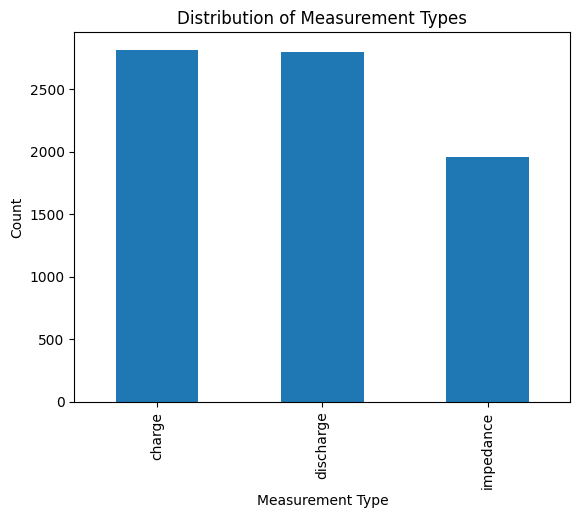

In [10]:
df['type'].value_counts().plot(kind='bar')

plt.title('Distribution of Measurement Types')
plt.xlabel('Measurement Type')
plt.ylabel('Count')
plt.show()

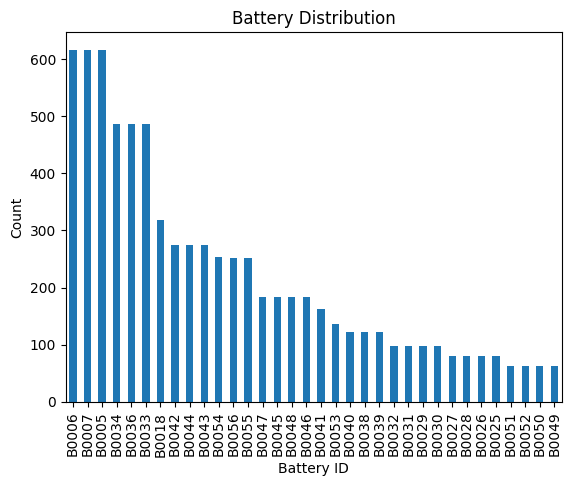

In [11]:
df['battery_id'].value_counts().plot(kind='bar')

plt.title('Battery Distribution')
plt.xlabel('Battery ID')
plt.ylabel('Count')
plt.show()

The NASA Battery Dataset contains multiple battery cells tested under different operating conditions. The metadata shows the presence of charging, discharging, and impedance measurements, which are important for battery state estimation research. Ambient temperature information is also available, enabling studies of temperature-dependent battery behavior.

The diversity of measurement types and operating conditions makes the dataset suitable for both machine learning-based and physics-based battery estimation techniques.


In [12]:
sample = pd.read_csv('00003.csv')

sample.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.486189,0.001417,5.990142,-0.0006,0.002,0.000
1,3.746592,1.489057,5.992528,1.4995,4.618,2.594
2,3.775438,1.490426,5.991340,1.4995,4.669,8.922
3,3.794844,1.491527,6.003554,1.4995,4.694,15.234
4,3.811691,1.491425,6.026729,1.4995,4.707,21.516


In [13]:
print(sample.shape)

sample.columns.tolist()

(1621, 6)


['Voltage_measured',
 'Current_measured',
 'Temperature_measured',
 'Current_charge',
 'Voltage_charge',
 'Time']

In [14]:
for col in sample.columns:
    print(col)

Voltage_measured
Current_measured
Temperature_measured
Current_charge
Voltage_charge
Time


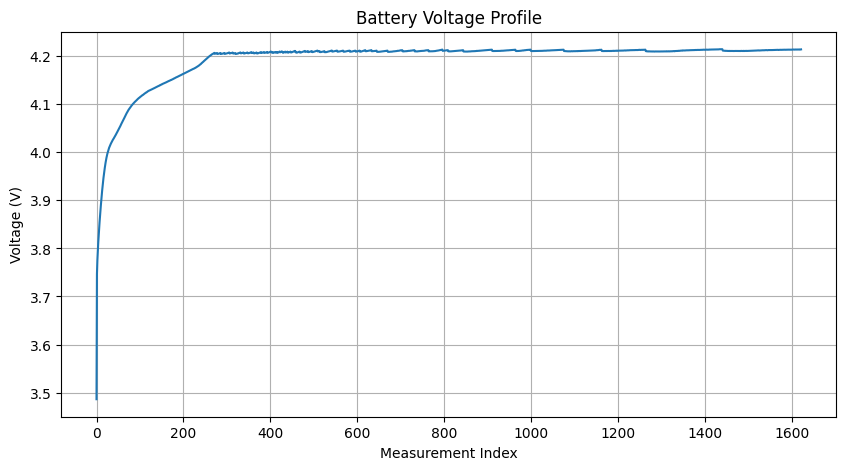

In [15]:
plt.figure(figsize=(10,5))
plt.plot(sample['Voltage_measured'])

plt.title('Battery Voltage Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Voltage (V)')
plt.grid(True)

plt.show()

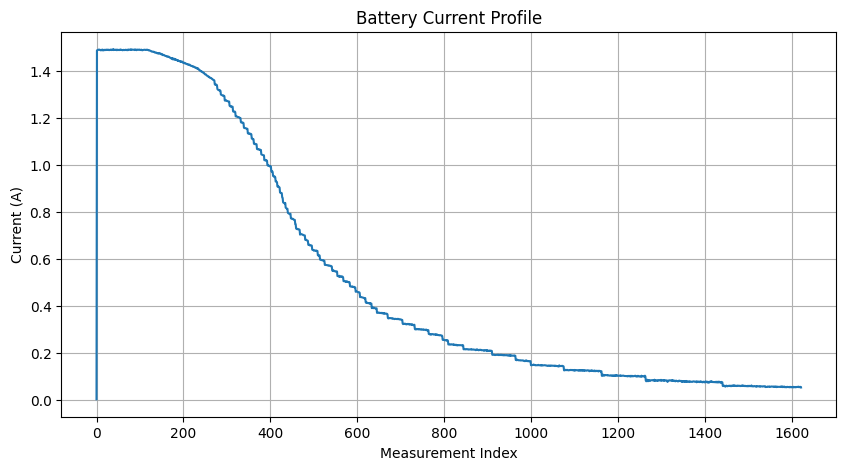

In [16]:
plt.figure(figsize=(10,5))
plt.plot(sample['Current_measured'])

plt.title('Battery Current Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Current (A)')
plt.grid(True)

plt.show()

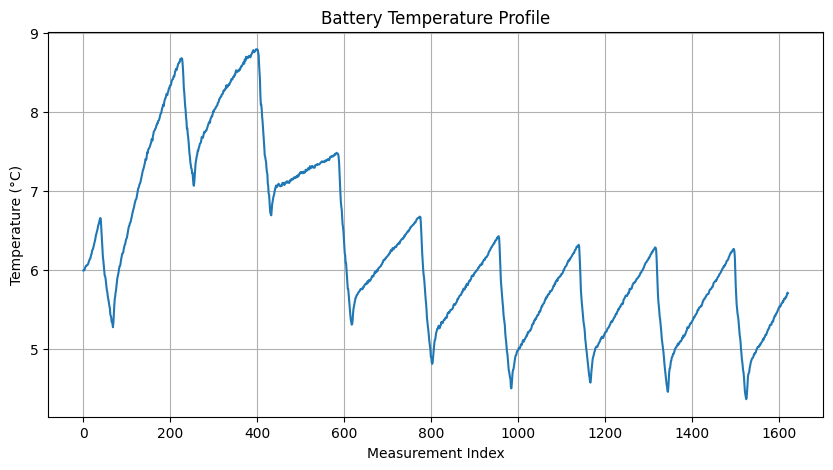

In [17]:
plt.figure(figsize=(10,5))
plt.plot(sample['Temperature_measured'])

plt.title('Battery Temperature Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Temperature (°C)')
plt.grid(True)

plt.show()

The selected NASA battery experiment contains time-series measurements of voltage, current, and temperature during battery operation. Voltage measurements provide information regarding battery charge state, current measurements capture charging and discharging behavior, and temperature measurements reflect thermal operating conditions.

These parameters are widely used as inputs for SOC estimation methods such as Coulomb Counting, Kalman Filters, and machine learning models. The availability of synchronized electrical and thermal measurements makes the NASA Battery Dataset highly suitable for battery state estimation research.


In [18]:
sample.isnull().sum()

,0
Voltage_measured,0
Current_measured,0
Temperature_measured,0
Current_charge,0
Voltage_charge,0
Time,0


In [19]:
sample.describe()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
count,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000
mean,4.193521,0.520792,6.279191,0.523551,4.508324,5363.634545
std,0.054022,0.525708,1.080534,0.528454,0.293705,3137.419230
min,3.486189,0.001417,4.358202,-0.000600,0.002000,0.000000
25%,4.207870,0.100997,5.461787,0.101300,4.288000,2636.422000
50%,4.210734,0.235531,6.024014,0.236000,4.364000,5357.266000
75%,4.211933,0.953625,7.116503,0.957700,4.757000,8080.719000
max,4.214595,1.494314,8.793624,1.499500,5.011000,10803.313000


The analyzed dataset contains continuous time-series measurements of battery voltage, current, and temperature. These variables are highly relevant for SOC and SOH estimation and can be directly used as input features for machine learning models such as Artificial Neural Networks (ANN), Long Short-Term Memory (LSTM) networks, Gated Recurrent Units (GRU), and other battery intelligence algorithms.

The dataset structure is suitable for supervised learning, time-series analysis, battery degradation studies, and TinyML-based battery estimation research.


## Oxford Battery Degradation Dataset Analysis

The Oxford Battery Degradation Dataset is a widely used public dataset for studying lithium-ion battery aging and long-term degradation behavior. The dataset contains battery cycling information collected under controlled laboratory conditions and is frequently used for SOH estimation, degradation prediction, and battery lifetime analysis.

Compared with the NASA Battery Dataset, the Oxford dataset places greater emphasis on long-term battery degradation and capacity fade analysis, making it particularly useful for battery health monitoring research.


In [20]:
from scipy.io import loadmat

oxford = loadmat('/content/Oxford_Battery_Degradation_Dataset_1[1].mat')

print(oxford.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8'])


In [21]:
print(type(oxford['Cell1']))
print(oxford['Cell1'].shape)

<class 'numpy.ndarray'>
(1, 1)


In [23]:
cell1 = oxford['Cell1']

cell1.dtype

dtype([('cyc0000', 'O'), ('cyc0100', 'O'), ('cyc0200', 'O'), ('cyc0300', 'O'), ('cyc0400', 'O'), ('cyc0500', 'O'), ('cyc0600', 'O'), ('cyc0700', 'O'), ('cyc0800', 'O'), ('cyc0900', 'O'), ('cyc1000', 'O'), ('cyc1100', 'O'), ('cyc1200', 'O'), ('cyc1300', 'O'), ('cyc1400', 'O'), ('cyc1600', 'O'), ('cyc1800', 'O'), ('cyc1900', 'O'), ('cyc2000', 'O'), ('cyc2100', 'O'), ('cyc2200', 'O'), ('cyc2300', 'O'), ('cyc2400', 'O'), ('cyc2500', 'O'), ('cyc2600', 'O'), ('cyc2700', 'O'), ('cyc2800', 'O'), ('cyc2900', 'O'), ('cyc3000', 'O'), ('cyc3100', 'O'), ('cyc3200', 'O'), ('cyc3300', 'O'), ('cyc3500', 'O'), ('cyc3600', 'O'), ('cyc3700', 'O'), ('cyc3800', 'O'), ('cyc3900', 'O'), ('cyc4000', 'O'), ('cyc4100', 'O'), ('cyc4200', 'O'), ('cyc4300', 'O'), ('cyc4400', 'O'), ('cyc4500', 'O'), ('cyc4600', 'O'), ('cyc4800', 'O'), ('cyc5000', 'O'), ('cyc5100', 'O'), ('cyc5200', 'O'), ('cyc5300', 'O'), ('cyc5400', 'O'), ('cyc5500', 'O'), ('cyc5600', 'O'), ('cyc5700', 'O'), ('cyc5800', 'O'), ('cyc5900', 'O'), ('c

### Dataset Structure Observation

The Oxford Battery Degradation Dataset is stored in MATLAB (.mat) format and contains battery-specific records organized into multiple cell structures (Cell1, Cell2, Cell3, etc.). This structure indicates that the dataset captures measurements from multiple battery cells over extended operating cycles, making it suitable for battery degradation analysis and SOH estimation research.


In [24]:
type(oxford['Cell1'])

numpy.ndarray

In [25]:
oxford['Cell1'].shape

(1, 1)

In [26]:
cell1 = oxford['Cell1']

print(type(cell1))
print(cell1.shape)
print(cell1.dtype)

<class 'numpy.ndarray'>
(1, 1)
[('cyc0000', 'O'), ('cyc0100', 'O'), ('cyc0200', 'O'), ('cyc0300', 'O'), ('cyc0400', 'O'), ('cyc0500', 'O'), ('cyc0600', 'O'), ('cyc0700', 'O'), ('cyc0800', 'O'), ('cyc0900', 'O'), ('cyc1000', 'O'), ('cyc1100', 'O'), ('cyc1200', 'O'), ('cyc1300', 'O'), ('cyc1400', 'O'), ('cyc1600', 'O'), ('cyc1800', 'O'), ('cyc1900', 'O'), ('cyc2000', 'O'), ('cyc2100', 'O'), ('cyc2200', 'O'), ('cyc2300', 'O'), ('cyc2400', 'O'), ('cyc2500', 'O'), ('cyc2600', 'O'), ('cyc2700', 'O'), ('cyc2800', 'O'), ('cyc2900', 'O'), ('cyc3000', 'O'), ('cyc3100', 'O'), ('cyc3200', 'O'), ('cyc3300', 'O'), ('cyc3500', 'O'), ('cyc3600', 'O'), ('cyc3700', 'O'), ('cyc3800', 'O'), ('cyc3900', 'O'), ('cyc4000', 'O'), ('cyc4100', 'O'), ('cyc4200', 'O'), ('cyc4300', 'O'), ('cyc4400', 'O'), ('cyc4500', 'O'), ('cyc4600', 'O'), ('cyc4800', 'O'), ('cyc5000', 'O'), ('cyc5100', 'O'), ('cyc5200', 'O'), ('cyc5300', 'O'), ('cyc5400', 'O'), ('cyc5500', 'O'), ('cyc5600', 'O'), ('cyc5700', 'O'), ('cyc5800', 'O

In [28]:
cell1.dtype.names

('cyc0000',
 'cyc0100',
 'cyc0200',
 'cyc0300',
 'cyc0400',
 'cyc0500',
 'cyc0600',
 'cyc0700',
 'cyc0800',
 'cyc0900',
 'cyc1000',
 'cyc1100',
 'cyc1200',
 'cyc1300',
 'cyc1400',
 'cyc1600',
 'cyc1800',
 'cyc1900',
 'cyc2000',
 'cyc2100',
 'cyc2200',
 'cyc2300',
 'cyc2400',
 'cyc2500',
 'cyc2600',
 'cyc2700',
 'cyc2800',
 'cyc2900',
 'cyc3000',
 'cyc3100',
 'cyc3200',
 'cyc3300',
 'cyc3500',
 'cyc3600',
 'cyc3700',
 'cyc3800',
 'cyc3900',
 'cyc4000',
 'cyc4100',
 'cyc4200',
 'cyc4300',
 'cyc4400',
 'cyc4500',
 'cyc4600',
 'cyc4800',
 'cyc5000',
 'cyc5100',
 'cyc5200',
 'cyc5300',
 'cyc5400',
 'cyc5500',
 'cyc5600',
 'cyc5700',
 'cyc5800',
 'cyc5900',
 'cyc6000',
 'cyc6100',
 'cyc6200',
 'cyc6300',
 'cyc6400',
 'cyc6500',
 'cyc6600',
 'cyc6700',
 'cyc6800',
 'cyc6900',
 'cyc7000',
 'cyc7100',
 'cyc7200',
 'cyc7300',
 'cyc7400',
 'cyc7500',
 'cyc7600',
 'cyc7700',
 'cyc7800',
 'cyc7900',
 'cyc8000',
 'cyc8100',
 'cyc8200')

In [30]:
cycle0 = cell1['cyc0000'][0,0]

print(type(cycle0))
print(cycle0.dtype)

<class 'numpy.ndarray'>
[('C1ch', 'O'), ('C1dc', 'O'), ('OCVch', 'O'), ('OCVdc', 'O')]


In [31]:
cycle0.dtype.names

('C1ch', 'C1dc', 'OCVch', 'OCVdc')

In [32]:
print(type(cycle0['OCVch']))
print(cycle0['OCVch'].shape)

<class 'numpy.ndarray'>
(1, 1)


In [33]:
cycle0['OCVch'][0,0]

array([[(array([[735956.06503505],
               [735956.06509292],
               [735956.06515079],
               ...,
               [735956.80577583],
               [735956.8058337 ],
               [735956.80585277]]), array([[2.7012479],
               [2.7262061],
               [2.7375548],
               ...,
               [4.199656 ],
               [4.1998568],
               [4.1998568]]), array([[-1.93715751e-06],
               [ 5.82076840e-02],
               [ 1.16418773e-01],
               ...,
               [ 7.44911192e+02],
               [ 7.44969106e+02],
               [ 7.44988190e+02]]), array([[39.984936],
               [39.926579],
               [39.95155 ],
               ...,
               [39.876675],
               [39.926579],
               [39.914112]]))                          ]],
      dtype=[('t', 'O'), ('v', 'O'), ('q', 'O'), ('T', 'O')])

In [35]:
ocv = cycle0['OCVch'][0,0]

print(type(ocv))
print(len(ocv))

<class 'numpy.ndarray'>
1


In [36]:
for i in range(len(ocv)):
    print(f"Array {i} shape:", ocv[i].shape)

Array 0 shape: (1,)


In [38]:
ocv = cycle0['OCVch'][0,0]

print("Shape:", ocv.shape)

for i in range(min(5, len(ocv))):
    print(f"\nElement {i}:")
    print(type(ocv[i]))

Shape: (1, 1)

Element 0:
<class 'numpy.ndarray'>


## Oxford Dataset Findings

1. Successfully loaded MATLAB (.mat) battery degradation dataset.
2. Dataset contains multiple battery cells (Cell1, Cell2, Cell3, etc.).
3. Data is organized according to battery cycle numbers.
4. OCV (Open Circuit Voltage) measurements are available.
5. Dataset is highly suitable for SOH estimation and degradation analysis.
6. MATLAB hierarchical structure makes preprocessing more complex than CSV-based datasets.

In [40]:
print(oxford.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8'])


## CALCE Battery Dataset Analysis

The CALCE Battery Dataset, developed by the Center for Advanced Life Cycle Engineering (University of Maryland), is a widely used dataset for battery aging, degradation analysis, and SOH estimation research. The dataset is organized into training and testing subsets, making it particularly suitable for machine learning model development and validation.

In [41]:
calce = pd.read_csv('/content/TFUDS_2580.csv')

calce.head()

,Data_Point,Test_Time_s_,Step_Time_s_,Step_Index,Cycle_Index,I,V,ChargeCapacityAh,Discharge_CapacityAh,Charge_EnergyWh,Discharge_EnergyWh,dV_dt_V_s_,Internal_Resistance_Ohm_,Is_FC_Data,AC_Impedance_Ohm_,ACI_Phase_Angle_Deg_,T,SOC,QAccu
0,2583,33039,7200.0000,6,1,0.000000,3.9539,2.001,0.40006,7.7061,1.5888,0.000000,0,0,0,0,25,0.8,5.551100e-17
1,2584,33040,1.0156,7,1,-0.000019,3.9537,2.001,0.40006,7.7061,1.5888,-0.000065,0,0,0,0,25,0.8,-6.993200e-09
2,2585,33041,2.0312,7,1,-0.000019,3.9539,2.001,0.40006,7.7061,1.5888,-0.000032,0,0,0,0,25,0.8,-1.751400e-08
3,2586,33042,3.0468,7,1,-0.000019,3.9539,2.001,0.40006,7.7061,1.5888,-0.000032,0,0,0,0,25,0.8,-2.883000e-08
4,2587,33043,4.0469,7,1,-0.000019,3.9539,2.001,0.40006,7.7061,1.5888,-0.000032,0,0,0,0,25,0.8,-4.044000e-08


In [43]:
for col in calce.columns:
    print(col)

Data_Point
Test_Time_s_
Step_Time_s_
Step_Index
Cycle_Index
I
V
ChargeCapacityAh
Discharge_CapacityAh
Charge_EnergyWh
Discharge_EnergyWh
dV_dt_V_s_
Internal_Resistance_Ohm_
Is_FC_Data
AC_Impedance_Ohm_
ACI_Phase_Angle_Deg_
T
SOC
QAccu


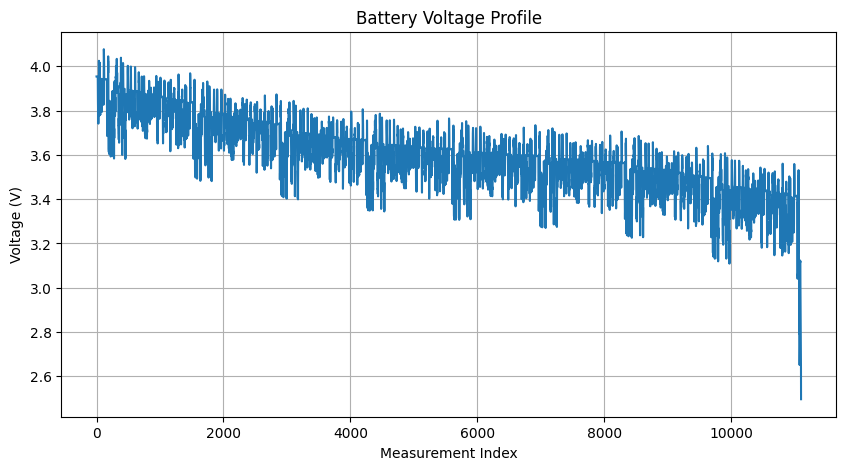

In [44]:
plt.figure(figsize=(10,5))
plt.plot(calce['V'])

plt.title('Battery Voltage Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Voltage (V)')
plt.grid(True)

plt.show()

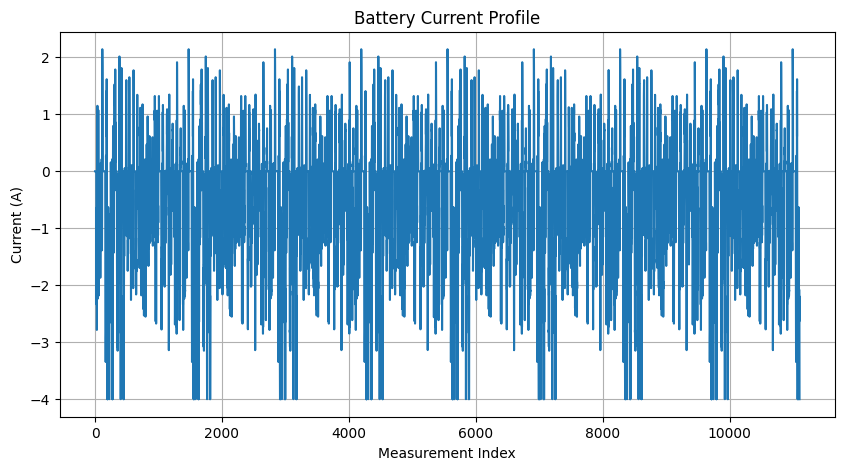

In [45]:
plt.figure(figsize=(10,5))
plt.plot(calce['I'])

plt.title('Battery Current Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Current (A)')
plt.grid(True)

plt.show()

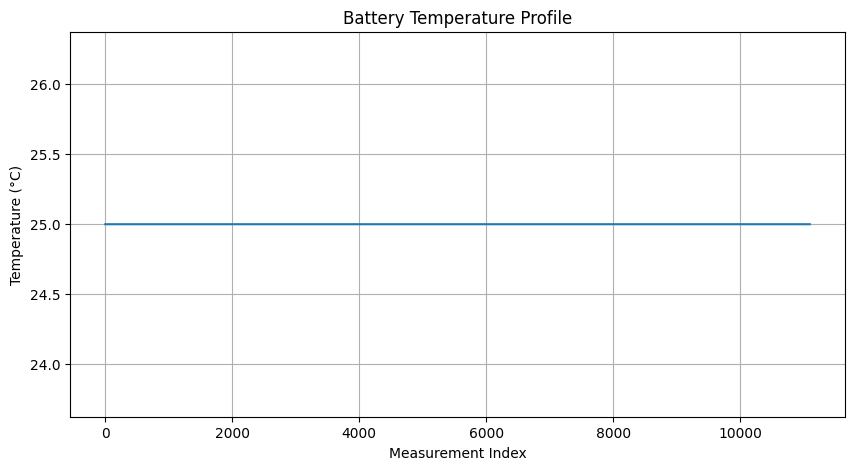

In [46]:
plt.figure(figsize=(10,5))
plt.plot(calce['T'])

plt.title('Battery Temperature Profile')
plt.xlabel('Measurement Index')
plt.ylabel('Temperature (°C)')
plt.grid(True)

plt.show()

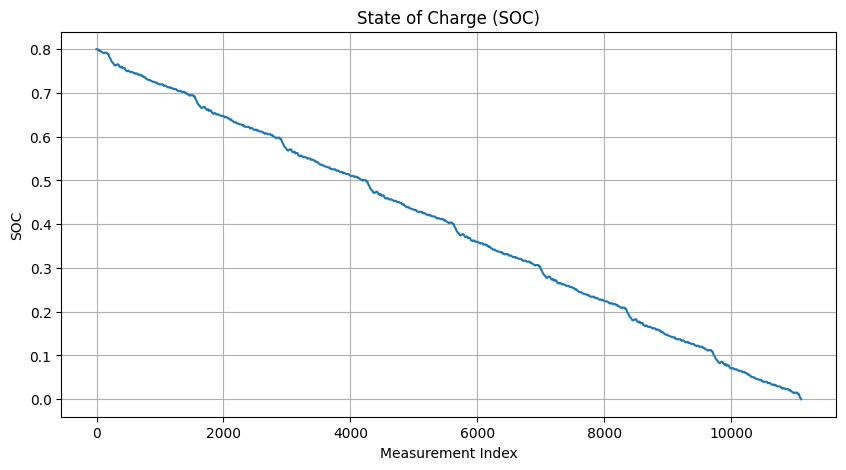

In [47]:
plt.figure(figsize=(10,5))
plt.plot(calce['SOC'])

plt.title('State of Charge (SOC)')
plt.xlabel('Measurement Index')
plt.ylabel('SOC')
plt.grid(True)

plt.show()

The CALCE Battery Dataset contains a comprehensive set of battery parameters including voltage, current, temperature, State of Charge (SOC), capacity measurements, energy measurements, and impedance characteristics. Unlike the NASA dataset, the CALCE dataset directly provides SOC information, making it highly valuable for supervised machine learning applications.

The availability of internal resistance and impedance measurements further enhances its usefulness for State of Health (SOH) estimation and battery degradation analysis.

The CALCE dataset is highly suitable for machine learning research because it provides both input features (voltage, current, temperature, impedance) and target variables such as SOC. The structured CSV format simplifies preprocessing and enables the development of supervised learning models including ANN, LSTM, GRU, Random Forest, and Support Vector Machine approaches.

| Dataset | Format | Key Parameters                                 | Main Application      | ML Suitability |
| ------- | ------ | ---------------------------------------------- | --------------------- | -------------- |
| NASA    | CSV    | Voltage, Current, Temperature                  | SOC/SOH Estimation    | High           |
| Oxford  | MAT    | OCV, Cycle Data                                | Battery Degradation   | High           |
| CALCE   | CSV    | Voltage, Current, Temperature, SOC, Resistance | SOC/SOH & ML Research | Very High      |


## Key Findings

1. NASA provides rich operational battery measurements useful for SOC and SOH estimation.
2. Oxford focuses on long-term battery degradation and cycle-based analysis.
3. CALCE provides a comprehensive battery dataset including SOC and impedance measurements.
4. CSV-based datasets are easier to preprocess than MATLAB datasets.
5. All three datasets are suitable for battery machine learning research.
6. CALCE appears particularly suitable for supervised learning because SOC labels are directly available.

## Conclusion

In this notebook, three publicly available lithium-ion battery datasets, namely the NASA Battery Dataset, Oxford Battery Degradation Dataset, and CALCE Battery Dataset, were studied and analyzed for battery state estimation research.

The NASA dataset provided detailed operational measurements including voltage, current, and temperature data, making it highly suitable for SOC and SOH estimation studies. The Oxford dataset demonstrated a cycle-based structure focused on battery degradation analysis and long-term health monitoring, which is particularly useful for SOH estimation and battery lifetime prediction. The CALCE dataset contained a comprehensive collection of battery parameters including voltage, current, temperature, SOC, capacity, and impedance measurements, making it highly suitable for machine learning and battery intelligence applications.

The analysis showed that each dataset offers unique advantages depending on the research objective. NASA is well suited for operational battery analysis, Oxford is valuable for degradation studies, and CALCE provides rich labeled data for supervised machine learning approaches. Overall, these datasets provide an excellent foundation for developing SOC estimation models, SOH prediction systems, battery degradation models, and future TinyML-based Battery Management Systems.


## Future Work

Future work will involve:
- Data preprocessing and cleaning
- Feature engineering
- Development of SOC estimation models
- Development of SOH prediction models
- Exploration of TinyML-based battery intelligence systems